### Use a dataset of customer product reviews (e.g., Amazon reviews) to classify the sentiment of each review as positive, negative, or neutral using a pre-trained machine learning model (e.g., Naïve Bayes). Evaluate the accuracy of your sentiment classifier.

In [53]:
import pandas as pd
import nltk
import re
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [54]:
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')

df = pd.read_csv('data_exp7.csv')
df.head(2)

,id,asins,brand,categories,colors,dateAdded,dateUpdated,dimension,ean,keys,...,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username,sizes,upc,weight
0,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I initially had trouble deciding between the p...,"Paperwhite voyage, no regrets!",NaN,NaN,Cristina M,NaN,NaN,205 grams
1,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,Allow me to preface this with a little history...,One Simply Could Not Ask For More,NaN,NaN,Ricky,NaN,NaN,205 grams


In [55]:
df.dropna(subset=['reviews.text', 'reviews.rating'], inplace=True)

df['full_review'] = (
    df['reviews.title'].fillna('') + ' ' +
    df['reviews.text'].fillna('')
)

df[['full_review', 'reviews.rating']].head(2)

,full_review,reviews.rating
0,"Paperwhite voyage, no regrets! I initially had...",5.0
1,One Simply Could Not Ask For More Allow me to ...,5.0


In [56]:
def map_sentiment(rating):
    if rating >= 4:
        return 'positive'
    elif rating == 3:
        return 'neutral'
    else:
        return 'negative'


df['sentiment'] = df['reviews.rating'].apply(map_sentiment)
print(df['sentiment'].value_counts())

sentiment
positive    977
neutral     124
negative     76
Name: count, dtype: int64


In [57]:
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)

    words = text.split()

    filtered_words = [
        word for word in words
        if word not in stop_words
    ]

    return ' '.join(filtered_words)

In [58]:
df['cleaned_review'] = df['full_review'].apply(preprocess_text)
df[['full_review', 'cleaned_review', 'sentiment']].head()

,full_review,cleaned_review,sentiment
0,"Paperwhite voyage, no regrets! I initially had...",paperwhite voyage regrets initially trouble de...,positive
1,One Simply Could Not Ask For More Allow me to ...,one simply could ask allow preface little hist...,positive
2,Great for those that just want an e-reader I a...,great want ereader enjoying far great reading ...,positive
3,Love / Hate relationship I bought one of the f...,love hate relationship bought one first paperw...,positive
4,I LOVE IT I have to say upfront - I don't like...,love say upfront dont like coroporate hermetic...,positive


In [59]:
X = df['cleaned_review']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 941
Testing samples: 236


In [60]:
vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

model = MultinomialNB()
model.fit(X_train_vec, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](3,)","[ 61., 99.,781.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](3,)","[-2.74,-2.25,-0.19]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[<U8](3,)","['negative','neutral','positive']"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](3, 5980)","[[ 0., 0., 1.,..., 0., 0., 0.], [ 0., 0., 8.,..., 0., 1., 0.], [ 1., 1.,23.,..., 2., 0., 1.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](3, 5980)","[[ -9.12, -9.12, -8.42,..., -9.12, -9.12, -9.12], [ -9.71, -9.71, -7.52,..., -9.71, -9.02, -9.71], [-10.34,-10.34, -7.85,..., -9.93,-11.03,-10.34]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5980


In [61]:
y_pred = model.predict(X_test_vec)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 88.56%


In [62]:
print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

              precision    recall  f1-score   support

    negative       0.57      0.27      0.36        15
     neutral       0.86      0.48      0.62        25
    positive       0.90      0.98      0.94       196

    accuracy                           0.89       236
   macro avg       0.78      0.58      0.64       236
weighted avg       0.87      0.89      0.87       236



In [63]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=['negative', 'neutral', 'positive']
)

print(cm)

[[  4   1  10]
 [  1  12  12]
 [  2   1 193]]


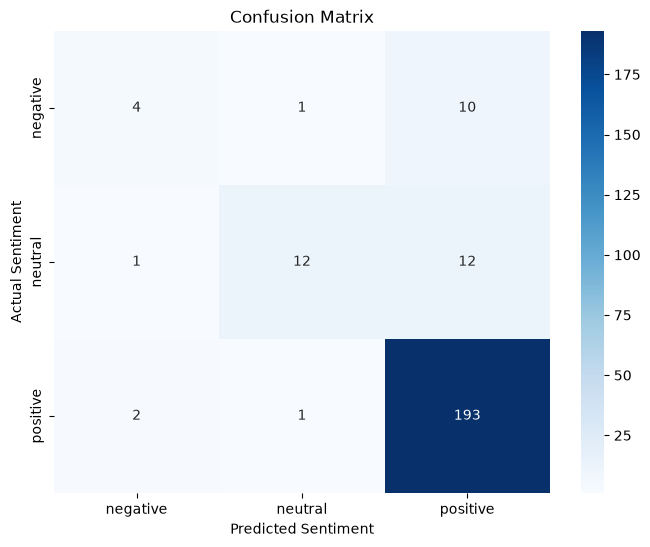

In [64]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['negative', 'neutral', 'positive'],
    yticklabels=['negative', 'neutral', 'positive']
)

plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.title('Confusion Matrix')

plt.show()